In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load RUS Results

In [18]:
results_dir = Path('./results/pamap')
result_files = sorted(results_dir.glob('*.npy'))
print(f'Found {len(result_files)} result file(s):')
for f in result_files:
    print(f'  {f.name}')

Found 4 result file(s):
  pamap_subject1_lag10_methodmultiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
  pamap_subject1_lag10_multiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
  pamap_subject1_lag5_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
  pamap_subject1_lag5_multiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy


In [19]:
def load_rus(file_path):
    data = np.load(file_path, allow_pickle=True)
    print(f'Loaded {len(data)} modality pairs from {Path(file_path).name}')
    return data

# Load all available files; key = filename stem
all_data = {f.stem: load_rus(f) for f in result_files}

Loaded 6 modality pairs from pamap_subject1_lag10_methodmultiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
Loaded 6 modality pairs from pamap_subject1_lag10_multiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
Loaded 6 modality pairs from pamap_subject1_lag5_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy
Loaded 6 modality pairs from pamap_subject1_lag5_multiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42.npy


## Inspect Structure

In [20]:
# Show the structure of one entry
sample_key = next(iter(all_data))
sample = all_data[sample_key]
entry = sample[0]

print('Keys in each pair entry:', list(entry.keys()))
print('Modality pairs:')
for pair in sample:
    print(f"  {pair['feature_pair'][0]} vs {pair['feature_pair'][1]}  "
          f"({pair['n_features_mod1']} / {pair['n_features_mod2']} features)")
print()
print('Metrics per lag:', list(entry['lag_results'][0].keys()))
print('Number of lags:', len(entry['lag_results']))

Keys in each pair entry: ['feature_pair', 'avg_metrics', 'lag_results', 'modality1_features', 'modality2_features', 'n_features_mod1', 'n_features_mod2']
Modality pairs:
  chest vs hand  (13 / 13 features)
  chest vs ankle  (13 / 13 features)
  chest vs heart_rate  (13 / 1 features)
  hand vs ankle  (13 / 13 features)
  hand vs heart_rate  (13 / 1 features)
  ankle vs heart_rate  (13 / 1 features)

Metrics per lag: ['lag', 'R_value', 'U1_value', 'U2_value', 'S_value', 'MI_value', 'R_norm', 'U1_norm', 'U2_norm', 'S_norm']
Number of lags: 11


## Build a Flat DataFrame

One row per (file, modality_pair, lag) for easy filtering and aggregation.

In [21]:
records = []
for file_stem, data in all_data.items():
    for pair_data in data:
        mod1, mod2 = pair_data['feature_pair']
        pair_label = f'{mod1} vs {mod2}'
        for lag_entry in pair_data['lag_results']:
            records.append({
                'file': file_stem,
                'mod1': mod1,
                'mod2': mod2,
                'pair': pair_label,
                'lag': lag_entry['lag'],
                'R': lag_entry['R_value'],
                'U1': lag_entry['U1_value'],
                'U2': lag_entry['U2_value'],
                'S': lag_entry['S_value'],
                'MI': lag_entry['MI_value'],
                'R_norm': lag_entry['R_norm'],
                'U1_norm': lag_entry['U1_norm'],
                'U2_norm': lag_entry['U2_norm'],
                'S_norm': lag_entry['S_norm'],
            })

df = pd.DataFrame(records)
# Replace inf with NaN for numeric operations
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(df.shape)
df.head()

(204, 14)


,file,mod1,mod2,pair,lag,R,U1,U2,S,MI,R_norm,U1_norm,U2_norm,S_norm
0,pamap_subject1_lag10_methodmultiscale_batch_di...,chest,hand,chest vs hand,0,3.484736,0.053130,0.007919,0.006196,3.551980,0.981068,0.014958,0.002229,0.001744
1,pamap_subject1_lag10_methodmultiscale_batch_di...,chest,hand,chest vs hand,1,3.485535,0.053085,0.007674,0.005613,3.551907,0.981313,0.014946,0.002161,0.001580
2,pamap_subject1_lag10_methodmultiscale_batch_di...,chest,hand,chest vs hand,2,3.485325,0.053482,0.007744,0.005287,3.551839,0.981273,0.015058,0.002180,0.001489
3,pamap_subject1_lag10_methodmultiscale_batch_di...,chest,hand,chest vs hand,3,3.487654,0.051220,0.007617,0.005432,3.551923,0.981906,0.014420,0.002144,0.001529
4,pamap_subject1_lag10_methodmultiscale_batch_di...,chest,hand,chest vs hand,4,3.487708,0.051469,0.007634,0.004897,3.551709,0.981980,0.014491,0.002150,0.001379


## Summary Table (averaged over lags)

In [22]:
summary = (
    df.groupby(['file', 'pair'])[['R', 'U1', 'U2', 'S', 'MI']]
    .mean()
    .round(4)
)
print(summary.to_string())

                                                                                                                                   R      U1      U2       S      MI
file                                                                                                     pair                                                       
pamap_subject1_lag10_methodmultiscale_batch_discrim_epochs30_ce_epochs20_n_batches1_batch_size512_seed42 ankle vs heart_rate  2.1755  1.3450  0.0026  0.0202  3.5433
                                                                                                         chest vs ankle       3.5030  0.0331  0.0101  0.0000  3.5440
                                                                                                         chest vs hand        3.4868  0.0517  0.0078  0.0055  3.5518
                                                                                                         chest vs heart_rate  2.1418  1.3900  0.0016  0.0102  3.5437
          

## RUS Values vs. Time Lag

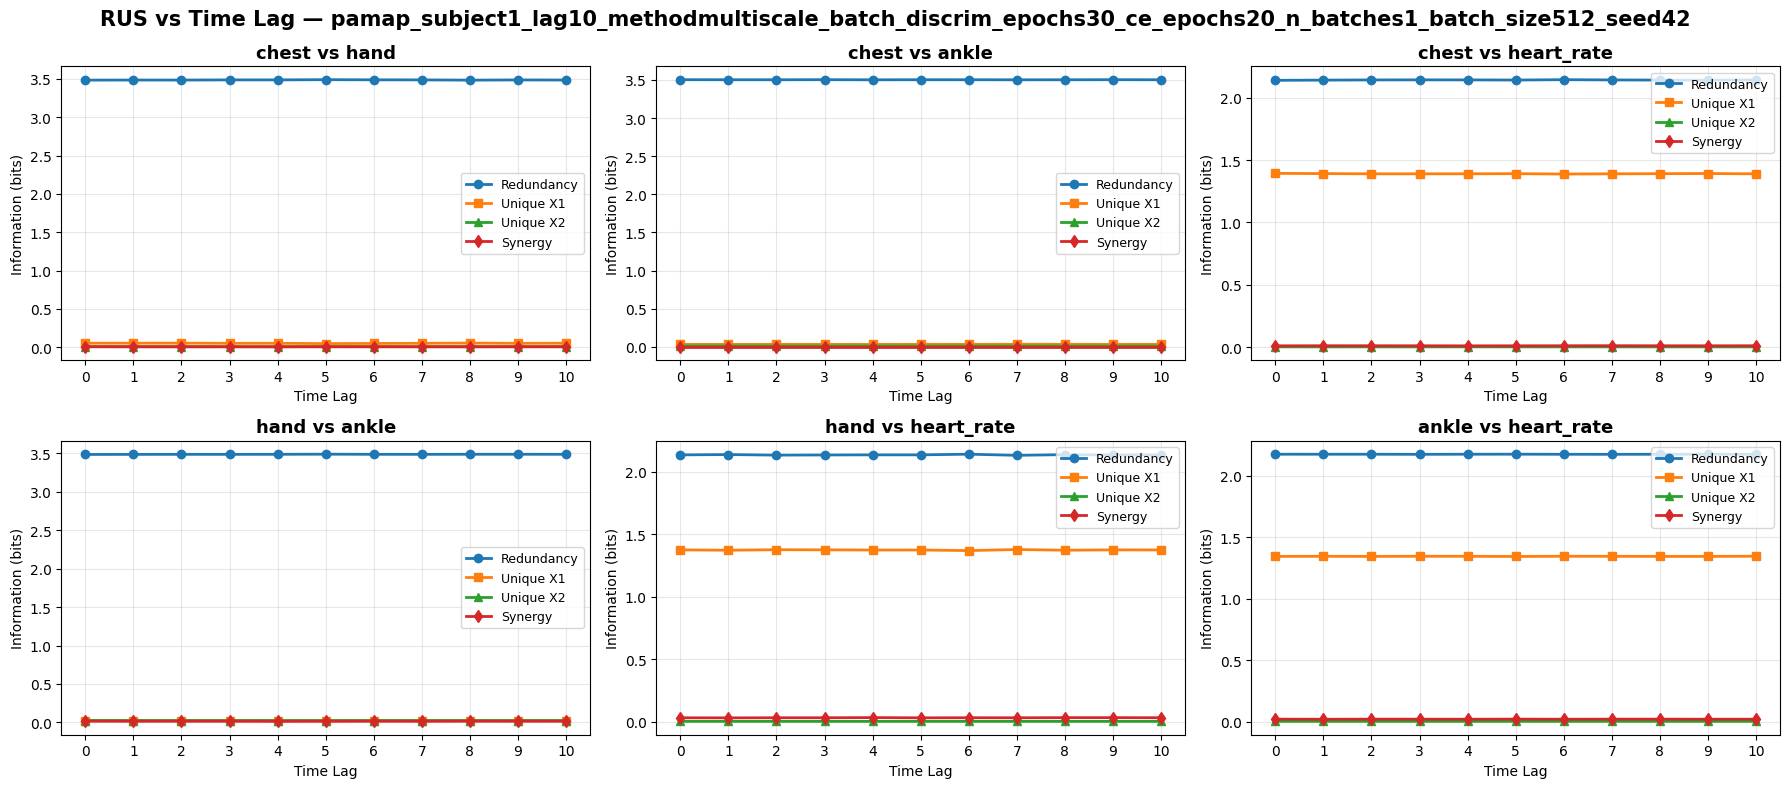

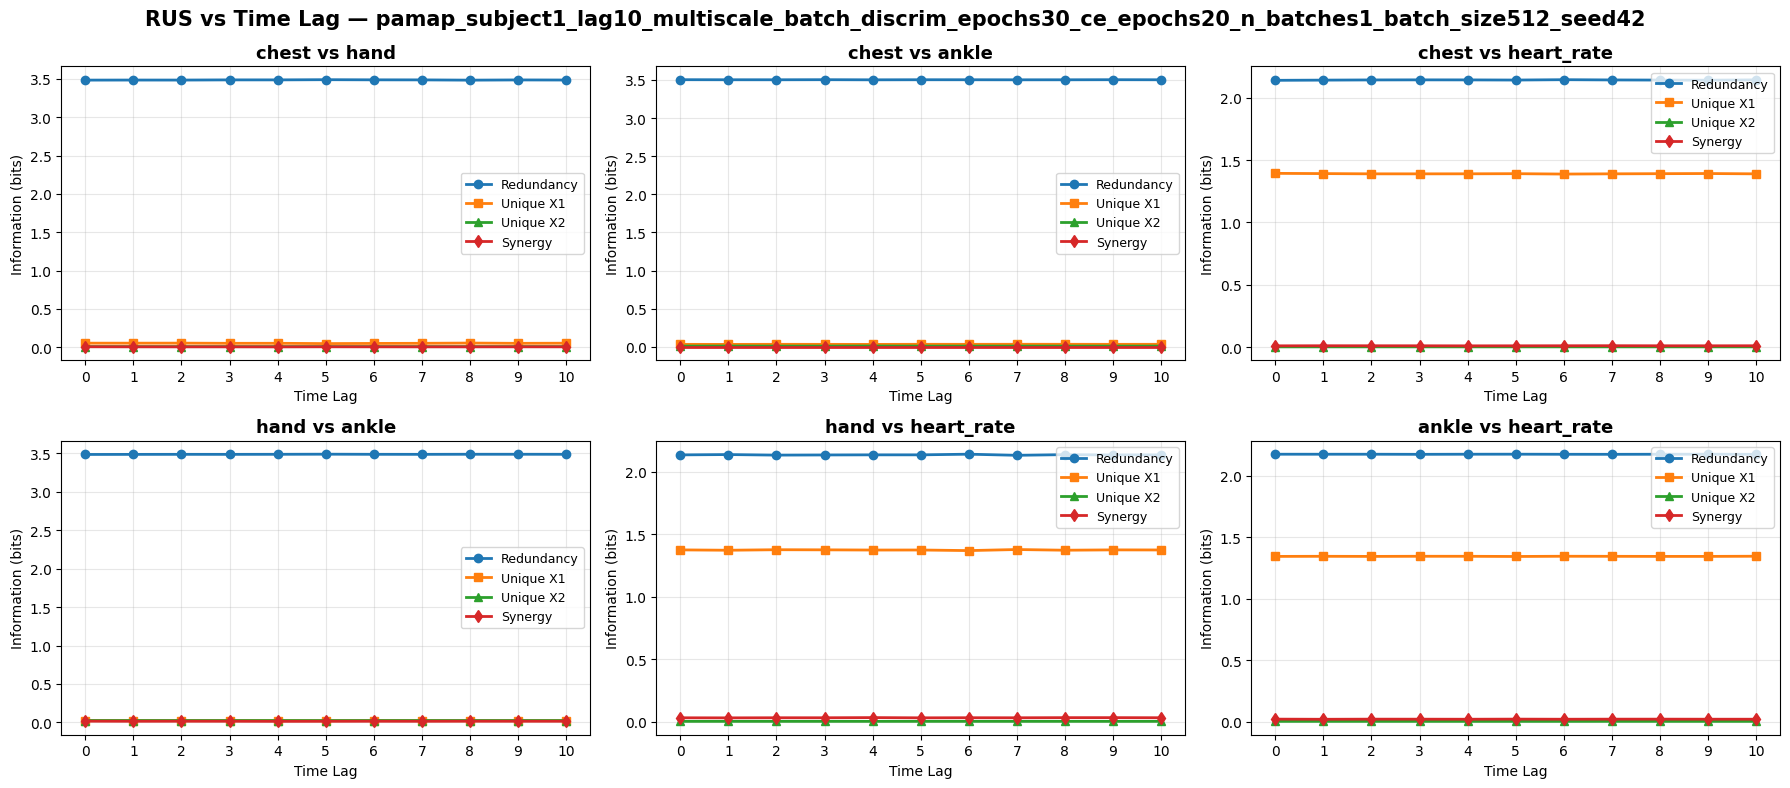

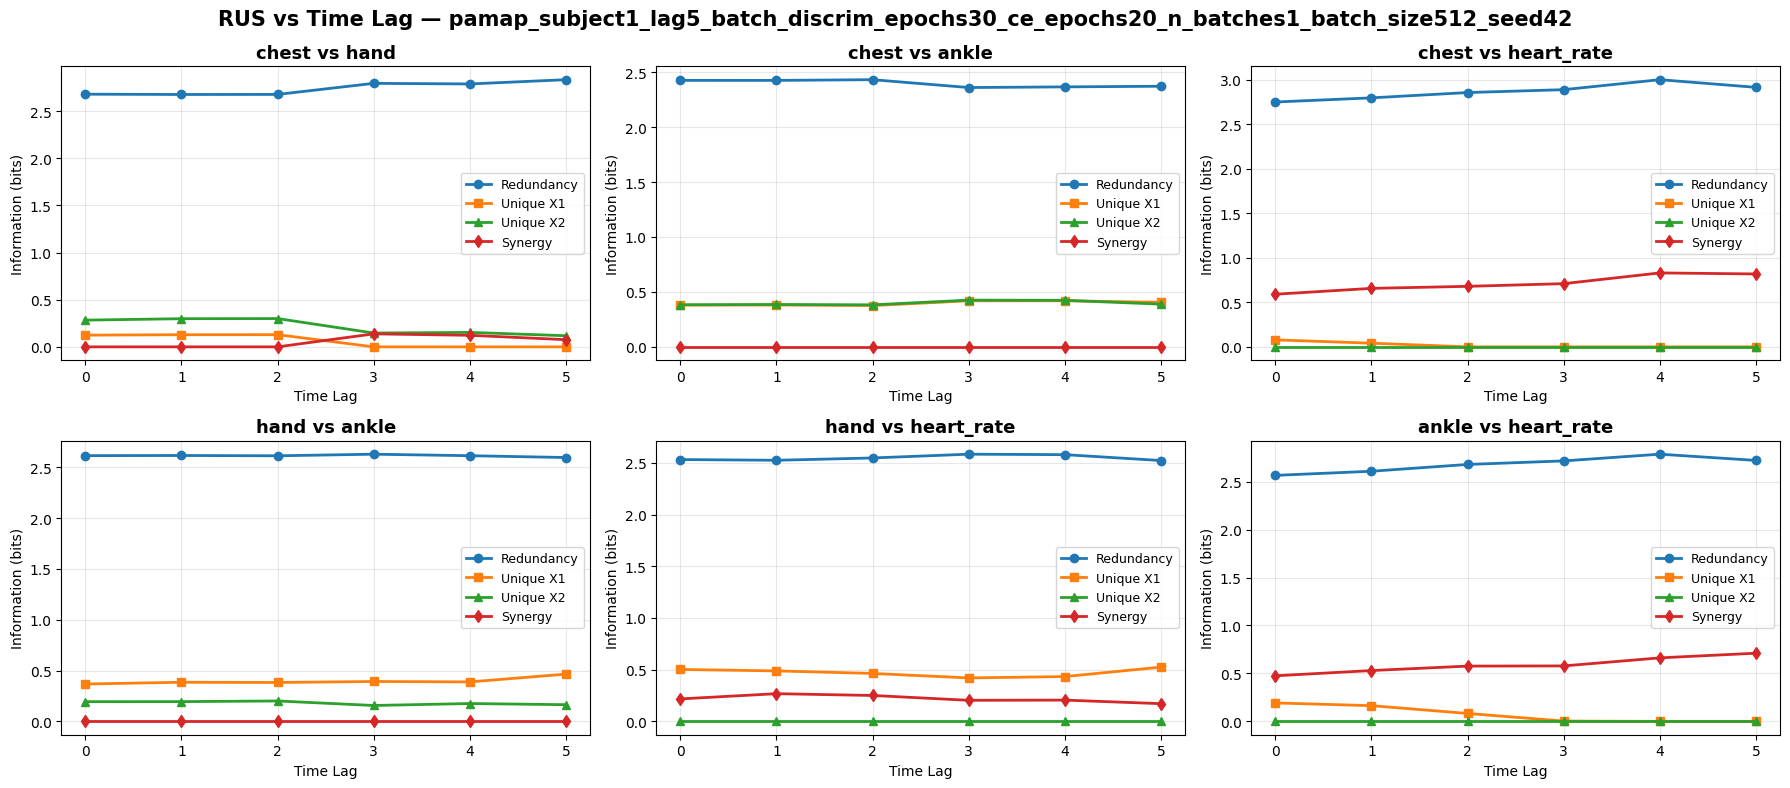

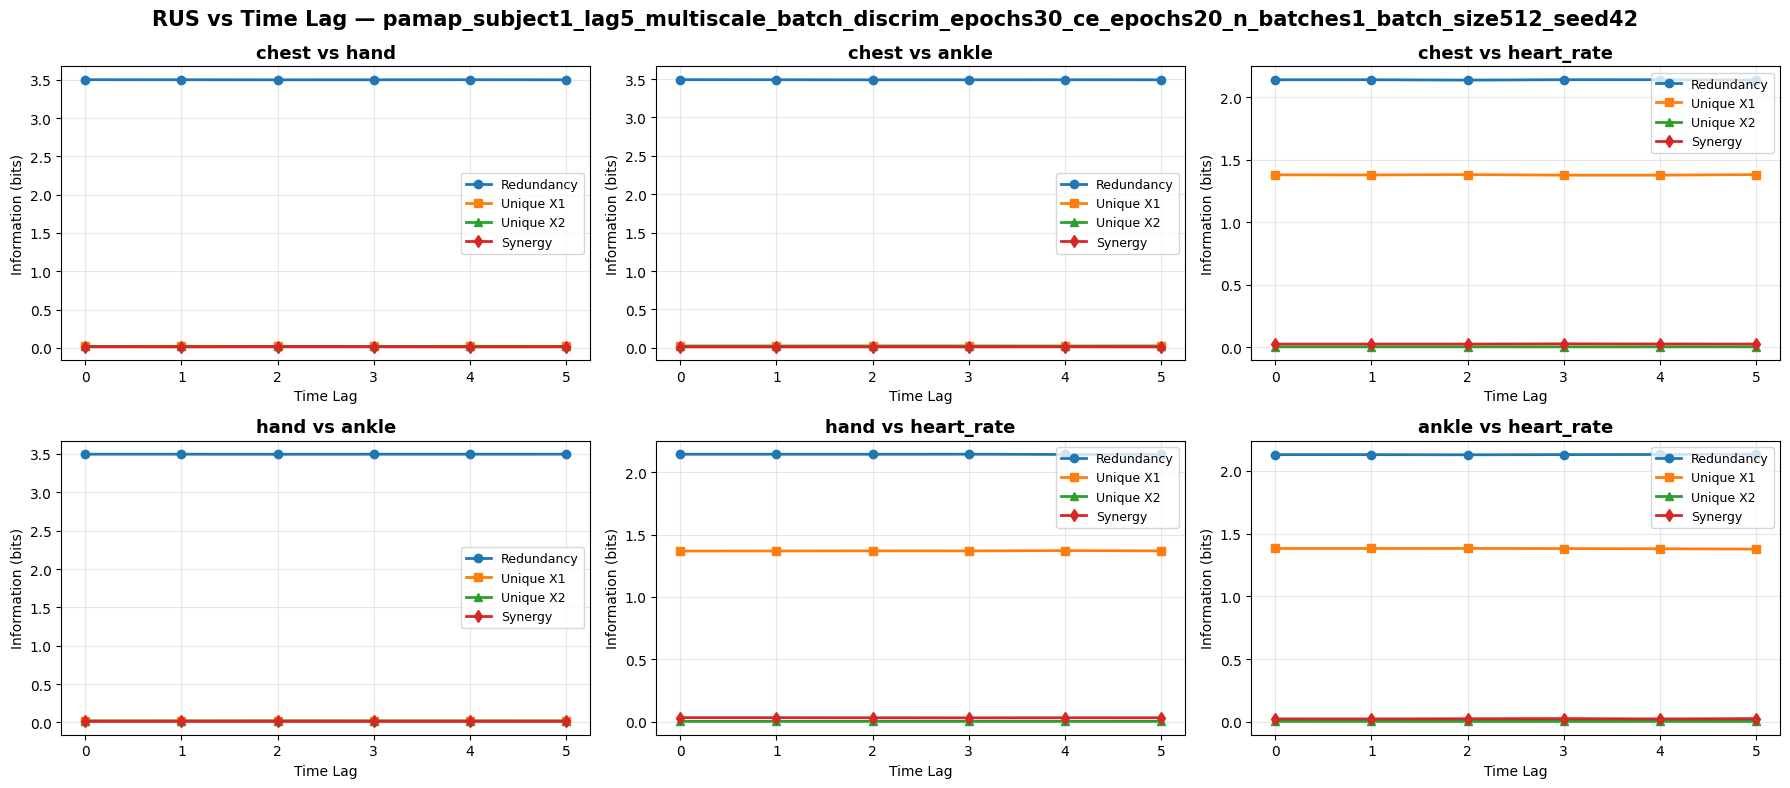

In [23]:
COLORS = {'R': '#1f77b4', 'U1': '#ff7f0e', 'U2': '#2ca02c', 'S': '#d62728'}
MARKERS = {'R': 'o', 'U1': 's', 'U2': '^', 'S': 'd'}

def plot_rus_vs_lag(df, file_filter=None, norm=False, save_path=None):
    subset = df if file_filter is None else df[df['file'] == file_filter]
    pairs = subset['pair'].unique()
    n_cols = min(3, len(pairs))
    n_rows = (len(pairs) + n_cols - 1) // n_cols

    metrics = ['R_norm', 'U1_norm', 'U2_norm', 'S_norm'] if norm else ['R', 'U1', 'U2', 'S']
    ylabel = 'Normalized (%)' if norm else 'Information (bits)'

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

    for idx, pair in enumerate(pairs):
        ax = axes[idx // n_cols][idx % n_cols]
        pdata = subset[subset['pair'] == pair].sort_values('lag')
        for m, label in zip(metrics, ['Redundancy', 'Unique X1', 'Unique X2', 'Synergy']):
            base = m.split('_')[0]  # 'R', 'U1', 'U2', 'S'
            vals = pdata[m] * 100 if norm else pdata[m]
            ax.plot(pdata['lag'], vals, marker=MARKERS[base], color=COLORS[base],
                    label=label, linewidth=2, markersize=6)
        ax.set_title(pair, fontsize=13, fontweight='bold')
        ax.set_xlabel('Time Lag')
        ax.set_ylabel(ylabel)
        ax.set_xticks(sorted(pdata['lag'].unique()))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        if norm:
            ax.set_ylim(0, 100)

    # Hide unused axes
    for idx in range(len(pairs), n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    title = file_filter or 'All files'
    fig.suptitle(f'RUS vs Time Lag — {title}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()


for file_stem in all_data:
    plot_rus_vs_lag(df, file_filter=file_stem)

## Normalized RUS (%) vs. Time Lag

In [ ]:
for file_stem in all_data:
    plot_rus_vs_lag(df, file_filter=file_stem, norm=True)

## Heatmap — Average RUS per Modality Pair

In [ ]:
for file_stem in all_data:
    pivot = (
        df[df['file'] == file_stem]
        .groupby('pair')[['R', 'U1', 'U2', 'S']]
        .mean()
    )
    fig, ax = plt.subplots(figsize=(7, max(3, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'bits'})
    ax.set_title(f'Avg RUS per Modality Pair — {file_stem}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

## Stacked Bar — Avg Normalized Composition per Pair

In [ ]:
for file_stem in all_data:
    comp = (
        df[df['file'] == file_stem]
        .groupby('pair')[['R_norm', 'U1_norm', 'U2_norm', 'S_norm']]
        .mean() * 100
    )
    comp.columns = ['Redundancy', 'Unique X1', 'Unique X2', 'Synergy']

    fig, ax = plt.subplots(figsize=(9, max(3, len(comp) * 0.7)))
    comp.plot(kind='barh', stacked=True,
              color=[COLORS['R'], COLORS['U1'], COLORS['U2'], COLORS['S']],
              ax=ax, edgecolor='white')
    ax.set_xlabel('Proportion (%)')
    ax.set_title(f'Avg Normalized RUS Composition — {file_stem}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()